# Notebook Jaguar Re-Identification avec ResNet

Un modèle **ResNet** en **classification supervisée**, puis on utilise la couche `embed_dense` pour produire des **embeddings** et calculer les **similarités cosinus** entre images de test.


# Les imports

In [23]:
import os
import gc
import json
import time
import datetime
import numpy as np
import pandas as pd
!pip install tensorflow
!pip install tensorboard
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import TensorBoard, EarlyStopping, ModelCheckpoint

from sklearn.metrics.pairwise import cosine_similarity

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 106.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 140.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 226.5/226.5 kB 25.6 MB/s eta 0:00:00


In [6]:
print('TensorFlow version :', tf.__version__)
print('GPU disponible :', tf.config.list_physical_devices('GPU'))


TensorFlow version : 2.21.0
GPU disponible : []


# Cnnection google drive

In [7]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


# Chemains et récupération data

In [26]:
data_path = '/content/drive/MyDrive/deep_learning_project/Deep_Learning_Project/jaguar/jaguar-re-id'

train_csv  = os.path.join(data_path, 'train.csv')
test_csv   = os.path.join(data_path, 'test.csv')
sample_csv = os.path.join(data_path, 'sample_submission.csv')

train_img_dir = os.path.join(data_path, 'train/train')
test_img_dir  = os.path.join(data_path, 'train/test/test')

results_dir = '/content/drive/MyDrive/jaguar/results'
os.makedirs(results_dir, exist_ok=True)

print('train_csv :', train_csv)
print('test_csv  :', test_csv)
print('train_img_dir :', train_img_dir)
print('test_img_dir  :', test_img_dir)
print('results_dir   :', results_dir)


train_csv : /content/drive/MyDrive/deep_learning_project/Deep_Learning_Project/jaguar/jaguar-re-id/train.csv
test_csv  : /content/drive/MyDrive/deep_learning_project/Deep_Learning_Project/jaguar/jaguar-re-id/test.csv
train_img_dir : /content/drive/MyDrive/deep_learning_project/Deep_Learning_Project/jaguar/jaguar-re-id/train/train
test_img_dir  : /content/drive/MyDrive/deep_learning_project/Deep_Learning_Project/jaguar/jaguar-re-id/train/test/test
results_dir   : /content/drive/MyDrive/jaguar/results


# Préparation dataframes

In [9]:
train_df = pd.read_csv(train_csv)
test_df = pd.read_csv(test_csv)
sample_df = pd.read_csv(sample_csv)

print('=== train_df ===')
print(train_df.head())
print(train_df.shape)

print('\n=== test_df ===')
print(test_df.head())
print(test_df.shape)

print('\n=== sample_df ===')
print(sample_df.head())
print(sample_df.shape)


=== train_df ===
         filename ground_truth
0  train_0001.png        Abril
1  train_0002.png        Abril
2  train_0003.png        Abril
3  train_0004.png       Akaloi
4  train_0005.png       Akaloi
(1895, 2)

=== test_df ===
   row_id    query_image  gallery_image
0       0  test_0001.png  test_0002.png
1       1  test_0001.png  test_0003.png
2       2  test_0001.png  test_0004.png
3       3  test_0001.png  test_0005.png
4       4  test_0001.png  test_0006.png
(137270, 3)

=== sample_df ===
   row_id  similarity
0       0    0.374540
1       1    0.950714
2       2    0.731994
3       3    0.598658
4       4    0.156019
(137270, 2)


# Encodage des labels

In [10]:
unique_labels = sorted(train_df['ground_truth'].unique())
label_map = {lab: i for i, lab in enumerate(unique_labels)}
inv_label_map = {i: lab for lab, i in label_map.items()}

train_df['label'] = train_df['ground_truth'].map(label_map)

num_classes = len(unique_labels)

print(f'Nombre de classes : {num_classes}')
print(f'Nombre total d\'images : {len(train_df)}')
print(train_df[['filename', 'ground_truth', 'label']].head())


Nombre de classes : 31
Nombre total d'images : 1895
         filename ground_truth  label
0  train_0001.png        Abril      0
1  train_0002.png        Abril      0
2  train_0003.png        Abril      0
3  train_0004.png       Akaloi      1
4  train_0005.png       Akaloi      1


# Définition params

In [12]:
IMG_SIZE = 128
BATCH_SIZE = 32
EPOCHS = 25

print('IMG_SIZE   =', IMG_SIZE)
print('BATCH_SIZE =', BATCH_SIZE)
print('EPOCHS     =', EPOCHS)


IMG_SIZE   = 128
BATCH_SIZE = 32
EPOCHS     = 25


# Prétratement

In [13]:
def create_datasets(batch_size=32, img_size=128, use_augmentation=True, val_ratio=0.15):
    autotune = tf.data.AUTOTUNE

    def load_image(path, y):
        img = tf.io.read_file(path)
        img = tf.image.decode_png(img, channels=3)
        img = tf.image.convert_image_dtype(img, tf.float32)
        img = tf.image.resize(img, (img_size, img_size))
        return img, y

    data_augmentation = None
    if use_augmentation:
        data_augmentation = keras.Sequential([
            layers.RandomFlip('horizontal'),
            layers.RandomRotation(0.05),
            layers.RandomZoom(0.10),
        ], name='augment')

    paths = train_df['filename'].apply(lambda x: os.path.join(train_img_dir, x)).values
    labels = train_df['label'].values

    base_ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    n_total = len(train_df)
    n_val = int(n_total * val_ratio)

    base_ds = base_ds.shuffle(n_total, seed=42, reshuffle_each_iteration=False)
    val_ds = base_ds.take(n_val)
    train_ds = base_ds.skip(n_val)

    train_ds = (
        train_ds
        .map(load_image, num_parallel_calls=autotune)
        .batch(batch_size)
        .prefetch(autotune)
    )

    val_ds = (
        val_ds
        .map(load_image, num_parallel_calls=autotune)
        .batch(batch_size)
        .prefetch(autotune)
    )

    return train_ds, val_ds, data_augmentation


In [14]:
train_ds, val_ds, data_aug = create_datasets(
    batch_size=BATCH_SIZE,
    img_size=IMG_SIZE,
    use_augmentation=True,
    val_ratio=0.15
)

print(train_ds)
print(val_ds)
print(data_aug)


<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>
<Sequential name=augment, built=False>


# Visualisation images

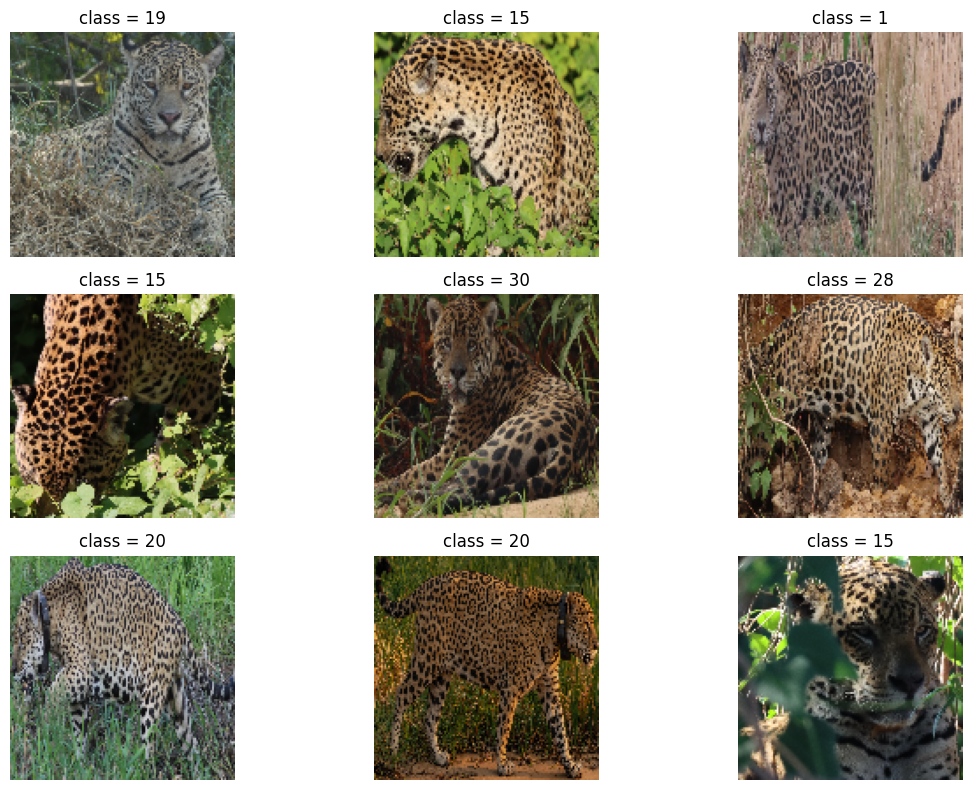

In [15]:
import matplotlib.pyplot as plt

images_batch, labels_batch = next(iter(train_ds))

plt.figure(figsize=(12, 8))
for i in range(min(9, len(images_batch))):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images_batch[i].numpy())
    plt.title(f'class = {labels_batch[i].numpy()}')
    plt.axis('off')
plt.tight_layout()
plt.show()


# Residual

In [16]:
def residual_block(x, filters, stride=1, l2_reg=0.0, name_prefix='block'):
    shortcut = x
    kernel_reg = regularizers.l2(l2_reg) if l2_reg > 0 else None

    x = layers.Conv2D(
        filters,
        kernel_size=3,
        strides=stride,
        padding='same',
        use_bias=False,
        kernel_regularizer=kernel_reg,
        name=f'{name_prefix}_conv1'
    )(x)
    x = layers.BatchNormalization(name=f'{name_prefix}_bn1')(x)
    x = layers.ReLU(name=f'{name_prefix}_relu1')(x)

    x = layers.Conv2D(
        filters,
        kernel_size=3,
        strides=1,
        padding='same',
        use_bias=False,
        kernel_regularizer=kernel_reg,
        name=f'{name_prefix}_conv2'
    )(x)
    x = layers.BatchNormalization(name=f'{name_prefix}_bn2')(x)

    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(
            filters,
            kernel_size=1,
            strides=stride,
            padding='same',
            use_bias=False,
            kernel_regularizer=kernel_reg,
            name=f'{name_prefix}_proj_conv'
        )(shortcut)
        shortcut = layers.BatchNormalization(name=f'{name_prefix}_proj_bn')(shortcut)

    x = layers.Add(name=f'{name_prefix}_add')([x, shortcut])
    x = layers.ReLU(name=f'{name_prefix}_out')(x)

    return x


# Build modèle

In [17]:
def build_resnet(
    img_size=124,
    num_classes=31,
    embedding_dim=256,
    dropout_rate=0.3,
    l2_reg=1e-4,
    data_augmentation=None
):
    inputs = keras.Input(shape=(img_size, img_size, 3), name='input_image')
    x = inputs

    if data_augmentation is not None:
        x = data_augmentation(x)

    kernel_reg = regularizers.l2(l2_reg) if l2_reg > 0 else None

    x = layers.Conv2D(
        64, kernel_size=7, strides=2, padding='same',
        use_bias=False, kernel_regularizer=kernel_reg, name='stem_conv'
    )(x)
    x = layers.BatchNormalization(name='stem_bn')(x)
    x = layers.ReLU(name='stem_relu')(x)
    x = layers.MaxPooling2D(pool_size=3, strides=2, padding='same', name='stem_pool')(x)

    x = residual_block(x, 64,  stride=1, l2_reg=l2_reg, name_prefix='conv2_1')
    x = residual_block(x, 64,  stride=1, l2_reg=l2_reg, name_prefix='conv2_2')
    x = residual_block(x, 64,  stride=1, l2_reg=l2_reg, name_prefix='conv2_3')

    x = residual_block(x, 128, stride=2, l2_reg=l2_reg, name_prefix='conv3_1')
    x = residual_block(x, 128, stride=1, l2_reg=l2_reg, name_prefix='conv3_2')
    x = residual_block(x, 128, stride=1, l2_reg=l2_reg, name_prefix='conv3_3')
    x = residual_block(x, 128, stride=1, l2_reg=l2_reg, name_prefix='conv3_4')

    x = residual_block(x, 256, stride=2, l2_reg=l2_reg, name_prefix='conv4_1')
    x = residual_block(x, 256, stride=1, l2_reg=l2_reg, name_prefix='conv4_2')
    x = residual_block(x, 256, stride=1, l2_reg=l2_reg, name_prefix='conv4_3')
    x = residual_block(x, 256, stride=1, l2_reg=l2_reg, name_prefix='conv4_4')
    x = residual_block(x, 256, stride=1, l2_reg=l2_reg, name_prefix='conv4_5')
    x = residual_block(x, 256, stride=1, l2_reg=l2_reg, name_prefix='conv4_6')

    x = residual_block(x, 512, stride=2, l2_reg=l2_reg, name_prefix='conv5_1')
    x = residual_block(x, 512, stride=1, l2_reg=l2_reg, name_prefix='conv5_2')
    x = residual_block(x, 512, stride=1, l2_reg=l2_reg, name_prefix='conv5_3')

    x = layers.GlobalAveragePooling2D(name='gap')(x)

    if dropout_rate > 0:
        x = layers.Dropout(dropout_rate, name='dropout_before_embed')(x)

    x = layers.Dense(
        embedding_dim,
        activation=None,
        kernel_regularizer=kernel_reg,
        name='embed_dense'
    )(x)

    x = layers.BatchNormalization(name='embed_bn')(x)
    x = layers.ReLU(name='embed_relu')(x)

    if dropout_rate > 0:
        x = layers.Dropout(dropout_rate, name='dropout_after_embed')(x)

    outputs = layers.Dense(num_classes, activation='softmax', name='cls')(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name='ResNet_classifier')
    return model


In [18]:
tmp_model = build_resnet
 (
    img_size=IMG_SIZE,
    num_classes=num_classes,
    embedding_dim=256,
    dropout_rate=0.3,
    l2_reg=1e-4,
    data_augmentation=data_aug
)

tmp_model.summary()


Model: "ResNet34_classifier"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_image         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ augment             │ (None, 128, 128,  │          0 │ input_image[0][0] │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 64, 64,    │      9,408 │ augment[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 64, 64,    │        256 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_relu (ReLU)    │ (None, 64, 64,    │          0 │ stem_bn[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_pool           │ (None, 32, 32,    │          0 │ stem_relu[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_1_conv1       │ (None, 32, 32,    │     36,864 │ stem_pool[0][0]   │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_1_bn1         │ (None, 32, 32,    │        256 │ conv2_1_conv1[0]… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_1_relu1       │ (None, 32, 32,    │          0 │ conv2_1_bn1[0][0] │
│ (ReLU)              │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_1_conv2       │ (None, 32, 32,    │     36,864 │ conv2_1_relu1[0]… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_1_bn2         │ (None, 32, 32,    │        256 │ conv2_1_conv2[0]… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_1_add (Add)   │ (None, 32, 32,    │          0 │ conv2_1_bn2[0][0… │
│                     │ 64)               │            │ stem_pool[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_1_out (ReLU)  │ (None, 32, 32,    │          0 │ conv2_1_add[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_2_conv1       │ (None, 32, 32,    │     36,864 │ conv2_1_out[0][0] │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_2_bn1         │ (None, 32, 32,    │        256 │ conv2_2_conv1[0]… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_2_relu1       │ (None, 32, 32,    │          0 │ conv2_2_bn1[0][0] │
│ (ReLU)              │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_2_conv2       │ (None, 32, 32,    │     36,864 │ conv2_2_relu1[0]

 Total params: 21,442,015 (81.79 MB)

 Trainable params: 21,424,479 (81.73 MB)

 Non-trainable params: 17,536 (68.50 KB)

# Entrainement modèle

In [19]:
def train_model(model, train_ds, val_ds, optimizer, experiment_name, epochs=25, patience=8):
    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    log_dir = 'logs/fit/' + experiment_name + '_' + datetime.datetime.now().strftime('%Y%m%d-%H%M%S')

    tensorboard_callback = TensorBoard(
        log_dir=log_dir,
        histogram_freq=1,
        write_graph=True,
        write_images=False,
        update_freq='epoch',
        profile_batch=0,
        embeddings_freq=0
    )

    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=patience,
        restore_best_weights=True,
        verbose=1
    )

    print('\n' + '=' * 70)
    print(f'Entrainement : {experiment_name}')
    print('=' * 70 + '\n')

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        callbacks=[early_stopping, tensorboard_callback],
        verbose=2,
    )

    results = {
        'experiment_name': experiment_name,
        'final_train_acc': float(history.history['accuracy'][-1]),
        'final_val_acc': float(history.history['val_accuracy'][-1]),
        'best_val_acc': float(max(history.history['val_accuracy'])),
        'final_train_loss': float(history.history['loss'][-1]),
        'final_val_loss': float(history.history['val_loss'][-1]),
        'epochs_trained': len(history.history['loss']),
    }

    print('\nRésultats :')
    print(f"  Train accuracy : {results['final_train_acc']:.4f}")
    print(f"  Val accuracy   : {results['final_val_acc']:.4f}")
    print(f"  Best val acc   : {results['best_val_acc']:.4f}")

    return model, history, results


In [20]:
def clear_memory():
    tf.keras.backend.clear_session()
    gc.collect()


## Tests d'hyperparamètres

Avec ResNet, on garde surtout les tests utiles :

- learning rate
- dropout
- taille de l'embedding
- optimizer


In [21]:
all_results = []


In [24]:
!pip install tensorboard

# Test 01

In [25]:
print('TEST 1 : LEARNING RATE')

learning_rates = [1e-3, 1e-4]

for lr in learning_rates:
    clear_memory()

    model = build_resnet(
        img_size=IMG_SIZE,
        num_classes=num_classes,
        embedding_dim=256,
        dropout_rate=0.3,
        l2_reg=1e-4,
        data_augmentation=data_aug
    )

    optimizer = keras.optimizers.Adam(learning_rate=lr)

    model, history, results = train_model(
        model,
        train_ds,
        val_ds,
        optimizer,
        experiment_name=f'resnet_lr_{lr}',
        epochs=EPOCHS,
        patience=8
    )

    results['config'] = {'learning_rate': lr}
    all_results.append(results)


TEST 1 : LEARNING RATE

Entrainement : resnet_lr_0.001

Epoch 1/25
51/51 - 83s - 2s/step - accuracy: 0.1421 - loss: 4.1291 - val_accuracy: 0.0528 - val_loss: 476.9298
Epoch 2/25
51/51 - 25s - 497ms/step - accuracy: 0.1850 - loss: 3.7338 - val_accuracy: 0.0528 - val_loss: 12.4906
Epoch 3/25
51/51 - 25s - 484ms/step - accuracy: 0.2241 - loss: 3.5101 - val_accuracy: 0.0176 - val_loss: 14.4223
Epoch 4/25
51/51 - 25s - 488ms/step - accuracy: 0.2731 - loss: 3.3141 - val_accuracy: 0.0493 - val_loss: 5.8617
Epoch 5/25
51/51 - 25s - 484ms/step - accuracy: 0.2967 - loss: 3.1778 - val_accuracy: 0.0458 - val_loss: 4.7410
Epoch 6/25
51/51 - 25s - 481ms/step - accuracy: 0.3451 - loss: 2.9325 - val_accuracy: 0.0669 - val_loss: 6.4286
Epoch 7/25
51/51 - 25s - 488ms/step - accuracy: 0.3768 - loss: 2.7835 - val_accuracy: 0.0563 - val_loss: 7.4482
Epoch 8/25
51/51 - 25s - 486ms/step - accuracy: 0.3855 - loss: 2.7177 - val_accuracy: 0.2254 - val_loss: 5.4500
Epoch 9/25
51/51 - 25s - 488ms/step - accuracy:

# Test 02

In [ ]:
print('TEST 2 : DROPOUT')

dropout_rates = [0.0, 0.3, 0.5]

for dr in dropout_rates:
    clear_memory()

    model = build_resnet(
        img_size=IMG_SIZE,
        num_classes=num_classes,
        embedding_dim=256,
        dropout_rate=dr,
        l2_reg=1e-4,
        data_augmentation=data_aug
    )

    optimizer = keras.optimizers.Adam(learning_rate=1e-4)

    model, history, results = train_model(
        model,
        train_ds,
        val_ds,
        optimizer,
        experiment_name=f'resnet_dropout_{dr}',
        epochs=EPOCHS,
        patience=8
    )

    results['config'] = {'dropout_rate': dr}
    all_results.append(results)


# Test 03

In [ ]:
print('TEST 3 : EMBEDDING DIMENSION')

embedding_dims = [128, 256, 512]

for emb_dim in embedding_dims:
    clear_memory()

    model = build_resnet(
        img_size=IMG_SIZE,
        num_classes=num_classes,
        embedding_dim=emb_dim,
        dropout_rate=0.3,
        l2_reg=1e-4,
        data_augmentation=data_aug
    )

    optimizer = keras.optimizers.Adam(learning_rate=1e-4)

    model, history, results = train_model(
        model,
        train_ds,
        val_ds,
        optimizer,
        experiment_name=f'resnet_emb_{emb_dim}',
        epochs=EPOCHS,
        patience=8
    )

    results['config'] = {'embedding_dim': emb_dim}
    all_results.append(results)


# Test 04

In [ ]:
print('TEST 4 : OPTIMIZER')

optimizers_to_test = [
    ('adam', keras.optimizers.Adam(learning_rate=1e-4)),
    ('sgd_momentum', keras.optimizers.SGD(learning_rate=1e-3, momentum=0.9)),
    ('rmsprop', keras.optimizers.RMSprop(learning_rate=1e-4)),
]

for opt_name, opt in optimizers_to_test:
    clear_memory()

    model = build_resnet(
        img_size=IMG_SIZE,
        num_classes=num_classes,
        embedding_dim=256,
        dropout_rate=0.3,
        l2_reg=1e-4,
        data_augmentation=data_aug
    )

    model, history, results = train_model(
        model,
        train_ds,
        val_ds,
        opt,
        experiment_name=f'resnet_opt_{opt_name}',
        epochs=EPOCHS,
        patience=8
    )

    results['config'] = {'optimizer': opt_name}
    all_results.append(results)


In [ ]:
df_results = pd.DataFrame(all_results)
df_results = df_results.sort_values('best_val_acc', ascending=False).reset_index(drop=True)

print(df_results.head(10))


In [ ]:
results_csv_path = os.path.join(results_dir, 'resnet_experiments.csv')
df_results.to_csv(results_csv_path, index=False)

print('Résultats sauvegardés dans :', results_csv_path)


In [ ]:
best_row = df_results.iloc[0]
best_row


In [ ]:
best_config = best_row['config']
if isinstance(best_config, str):
    best_config = eval(best_config)

print('Meilleure config :', best_config)


In [ ]:
clear_memory()

best_learning_rate = best_config.get('learning_rate', 1e-4)
best_dropout = best_config.get('dropout_rate', 0.3)
best_embedding_dim = best_config.get('embedding_dim', 256)
best_optimizer_name = best_config.get('optimizer', 'adam')

if best_optimizer_name == 'adam':
    final_optimizer = keras.optimizers.Adam(learning_rate=best_learning_rate)
elif best_optimizer_name == 'sgd_momentum':
    final_optimizer = keras.optimizers.SGD(learning_rate=1e-3, momentum=0.9)
elif best_optimizer_name == 'rmsprop':
    final_optimizer = keras.optimizers.RMSprop(learning_rate=1e-4)
else:
    final_optimizer = keras.optimizers.Adam(learning_rate=1e-4)

final_model = build_resnet(
    img_size=IMG_SIZE,
    num_classes=num_classes,
    embedding_dim=best_embedding_dim,
    dropout_rate=best_dropout,
    l2_reg=1e-4,
    data_augmentation=data_aug
)

final_model, final_history, final_results = train_model(
    final_model,
    train_ds,
    val_ds,
    final_optimizer,
    experiment_name='FINAL_ResNet',
    epochs=25,
    patience=12
)

print(final_results)


In [ ]:
%load_ext tensorboard
%tensorboard --logdir logs/fit


# Genération de la submission

In [ ]:
def generate_submission(model, img_size=224, output_name='submission_resnet.csv'):
    autotune = tf.data.AUTOTUNE

    def load_test_image(path):
        img = tf.io.read_file(path)
        img = tf.image.decode_png(img, channels=3)
        img = tf.image.convert_image_dtype(img, tf.float32)
        img = tf.image.resize(img, (img_size, img_size))
        return img

    test_df = pd.read_csv(test_csv)

    unique_imgs = sorted(set(test_df['query_image']) | set(test_df['gallery_image']))
    print(f'Nombre d\'images uniques dans test : {len(unique_imgs)}')

    test_paths = [os.path.join(test_img_dir, img) for img in unique_imgs]

    test_ds = (
        tf.data.Dataset.from_tensor_slices(tf.constant(test_paths))
        .map(load_test_image, num_parallel_calls=autotune)
        .batch(BATCH_SIZE)
        .prefetch(autotune)
    )

    embedding_model = keras.Model(
        inputs=model.inputs,
        outputs=model.get_layer('embed_dense').output
    )

    print('Extraction des embeddings...')
    embeddings = embedding_model.predict(test_ds, verbose=1)

    embeddings = embeddings / (np.linalg.norm(embeddings, axis=1, keepdims=True) + 1e-12)

    print('Calcul des similarités...')
    similarity_matrix = cosine_similarity(embeddings)
    similarity_matrix = (similarity_matrix + 1.0) / 2.0
    similarity_matrix = np.clip(similarity_matrix, 0.0, 1.0)

    img_to_idx = {img: idx for idx, img in enumerate(unique_imgs)}

    similarities = []
    for _, row in test_df.iterrows():
        qi = img_to_idx[row['query_image']]
        gi = img_to_idx[row['gallery_image']]
        similarities.append(float(similarity_matrix[qi, gi]))

    submission = pd.DataFrame({
        'row_id': test_df['row_id'],
        'similarity': similarities
    })

    out_path = os.path.join(results_dir, output_name)
    submission.to_csv(out_path, index=False)

    print(f'\nFichier de soumission créé : {out_path}')
    print(f'Nombre de lignes         : {len(submission)}')
    print(f'Similarité moyenne       : {submission["similarity"].mean():.4f}')
    print(f'Similarité min           : {submission["similarity"].min():.4f}')
    print(f'Similarité max           : {submission["similarity"].max():.4f}')

    return submission, out_path


In [ ]:
submission, submission_path = generate_submission(
    final_model,
    img_size=IMG_SIZE,
    output_name='submission_resnet.csv'
)


In [ ]:
submission.head()


In [ ]:
model_save_path = os.path.join(results_dir, 'final_resnet_model.keras')
final_model.save(model_save_path)

print('Modèle sauvegardé :', model_save_path)


In [ ]:
history_path = os.path.join(results_dir, 'final_resnet_history.json')

with open(history_path, 'w') as f:
    json.dump(final_history.history, f)

print('Historique sauvegardé :', history_path)


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(final_history.history['loss'], label='train loss')
plt.plot(final_history.history['val_loss'], label='val loss')
plt.legend()
plt.title('Loss')
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(final_history.history['accuracy'], label='train acc')
plt.plot(final_history.history['val_accuracy'], label='val acc')
plt.legend()
plt.title('Accuracy')
plt.show()
